# wPINNs vs Lax-Friedrichs vs Godunov — Burgers' Equation

Two Riemann problems:
- **Rarefaction**: u₀ = −1 (x≤0), +1 (x>0)
- **Moving shock**: u₀ = 1 (x≤0), 0 (x>0)

Domain: x ∈ [−1, 1], t ∈ [0, 0.45]

Pre-trained wPINNs models live in `RarefactionWave/` (rarefaction) and  
`ShockWave/` (shock — train first with `what_solving = 'Moving'` in `ShockRarEntropy.py`).

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Make sure repo modules are importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from lax_friedrichs import lax_friedrichs, exact_solution, l1_error, relative_l1_error
from godunov import godunov

## Configuration

In [2]:
# Paths to best pre-trained wPINNs models.
# Setup_39 / Retrain_0 is the best rarefaction run per best.csv (rel L1 = 0.0175).
# Change SHOCK_MODEL_PATH once you have trained the shock model.
RAREFACTION_MODEL_PATH = "RarefactionWave/Setup_39/Retrain_0/ModelSol.pkl"
SHOCK_MODEL_PATH       = "ShockWave/best/ModelSol.pkl"   # set after training

# Lax-Friedrichs resolution
LF_NX  = 500
LF_CFL = 0.9

# Time slices to compare at
TIME_SLICES = [0.10, 0.25, 0.45]

T_FINAL = 0.45

## Helper: load wPINNs model

In [3]:
def load_wpinns_model(path):
    """Load a serialised wPINNs solution network. Returns None if not found."""
    if not os.path.exists(path):
        print(f"[wPINNs] Model not found at '{path}' — skipping wPINNs panel.")
        return None
    model = torch.load(path, map_location="cpu", weights_only=False)
    model.eval()
    print(f"[wPINNs] Loaded model from '{path}'")
    return model


def wpinns_predict(model, x_np: np.ndarray, t_val: float) -> np.ndarray:
    """Evaluate model on (t_val, x_np) and return u as a numpy array."""
    t_col = np.full_like(x_np, t_val)
    inp = torch.tensor(np.column_stack([t_col, x_np]), dtype=torch.float32)
    with torch.no_grad():
        out = model(inp).numpy().reshape(-1)
    return out

## Helper: find LF solution at a given time

In [4]:
def lf_at_time(x_lf, t_vec, U_lf, t_query):
    """Return the LF solution array closest to t_query."""
    idx = int(np.argmin(np.abs(t_vec - t_query)))
    return U_lf[idx], t_vec[idx]

---
## Case 1 — Rarefaction Wave

In [5]:
case = "Rarefaction"

# --- Lax-Friedrichs ---
x_lf, t_vec_lf, U_lf = lax_friedrichs(case, nx=LF_NX, cfl=LF_CFL)
print(f"LF: {len(t_vec_lf)} time steps, final t = {t_vec_lf[-1]:.4f}")

# --- Godunov (same grid / CFL) ---
x_gd, t_vec_gd, U_gd = godunov(case, nx=LF_NX, cfl=LF_CFL)
print(f"Godunov: {len(t_vec_gd)} time steps, final t = {t_vec_gd[-1]:.4f}")

# --- wPINNs ---
model_rar = load_wpinns_model(RAREFACTION_MODEL_PATH)

LF: 127 time steps, final t = 0.4500
Godunov: 127 time steps, final t = 0.4500
[wPINNs] Loaded model from 'RarefactionWave/Setup_39/Retrain_0/ModelSol.pkl'


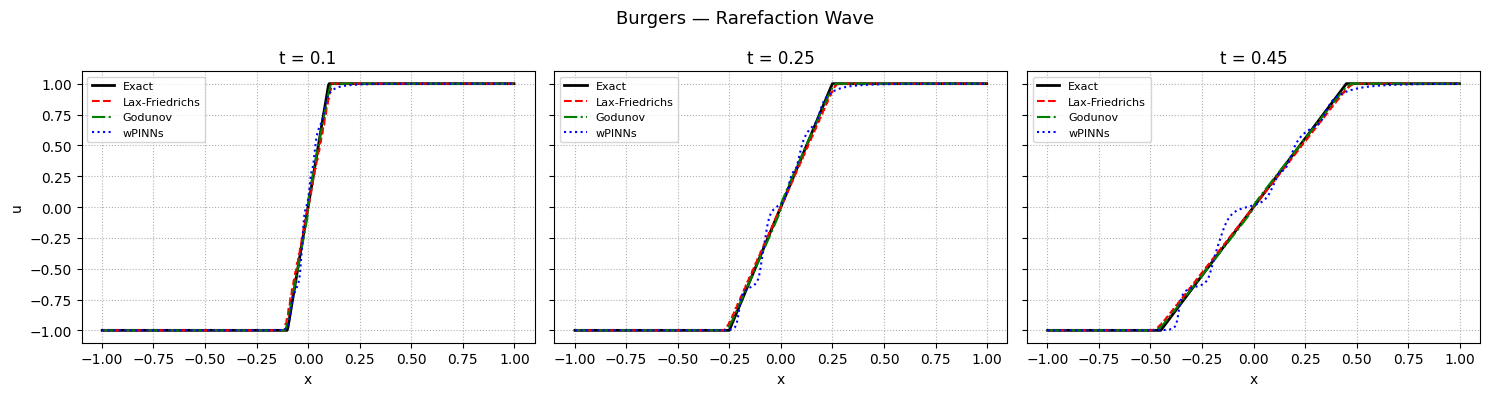

In [6]:
fig, axes = plt.subplots(1, len(TIME_SLICES), figsize=(5 * len(TIME_SLICES), 4), sharey=True)
fig.suptitle("Burgers — Rarefaction Wave", fontsize=13)

for ax, t_q in zip(axes, TIME_SLICES):
    u_ex = exact_solution(case, x_lf, t_q)
    u_lf, t_actual = lf_at_time(x_lf, t_vec_lf, U_lf, t_q)
    u_gd, _        = lf_at_time(x_gd, t_vec_gd, U_gd, t_q)

    ax.plot(x_lf, u_ex,  "k-",  lw=2,   label="Exact")
    ax.plot(x_lf, u_lf,  "r--", lw=1.5, label="Lax-Friedrichs")
    ax.plot(x_gd, u_gd,  "g-.", lw=1.5, label="Godunov")
    if model_rar is not None:
        u_wp = wpinns_predict(model_rar, x_lf, t_q)
        ax.plot(x_lf, u_wp, "b:", lw=1.5, label="wPINNs")

    ax.set_title(f"t = {t_q}")
    ax.set_xlabel("x")
    ax.grid(True, ls=":")
    ax.legend(fontsize=8)

axes[0].set_ylabel("u")
plt.tight_layout()
plt.savefig("comparison_rarefaction_slices.png", dpi=150)
plt.show()

In [7]:
# Error table at final time T = 0.45
u_ex_final = exact_solution(case, x_lf, T_FINAL)
u_lf_final, _ = lf_at_time(x_lf, t_vec_lf, U_lf, T_FINAL)
u_gd_final, _ = lf_at_time(x_gd, t_vec_gd, U_gd, T_FINAL)

print("=== Rarefaction — errors at t = 0.45 ===")
print(f"{'Method':<18} {'L1 error':>12} {'Rel L1 error':>14}")
print("-" * 46)
print(f"{'Lax-Friedrichs':<18} {l1_error(u_lf_final, u_ex_final):>12.6f} {relative_l1_error(u_lf_final, u_ex_final):>14.6f}")
print(f"{'Godunov':<18} {l1_error(u_gd_final, u_ex_final):>12.6f} {relative_l1_error(u_gd_final, u_ex_final):>14.6f}")
if model_rar is not None:
    u_wp_final = wpinns_predict(model_rar, x_lf, T_FINAL)
    print(f"{'wPINNs':<18} {l1_error(u_wp_final, u_ex_final):>12.6f} {relative_l1_error(u_wp_final, u_ex_final):>14.6f}")

=== Rarefaction — errors at t = 0.45 ===
Method                 L1 error   Rel L1 error
----------------------------------------------
Lax-Friedrichs         0.009852       0.012713
Godunov                0.004838       0.006243
wPINNs                 0.028214       0.036404


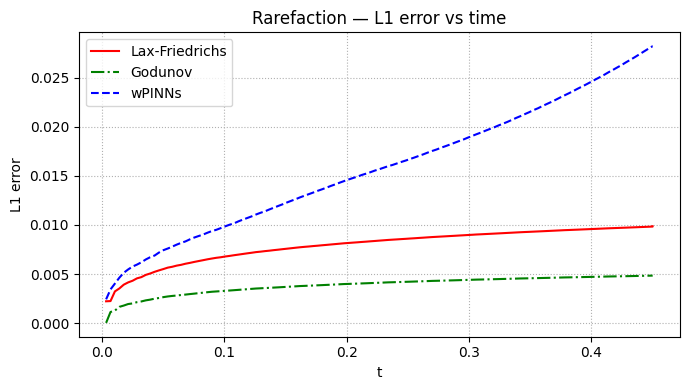

In [8]:
# Error vs time plot
t_sample = t_vec_lf[::max(1, len(t_vec_lf) // 100)]  # ~100 points
lf_errors = []
gd_errors = []
wp_errors = []

for t_q in t_sample:
    if t_q == 0:
        continue
    u_ex_t = exact_solution(case, x_lf, t_q)
    u_lf_t, _ = lf_at_time(x_lf, t_vec_lf, U_lf, t_q)
    u_gd_t, _ = lf_at_time(x_gd, t_vec_gd, U_gd, t_q)
    lf_errors.append(l1_error(u_lf_t, u_ex_t))
    gd_errors.append(l1_error(u_gd_t, u_ex_t))
    if model_rar is not None:
        u_wp_t = wpinns_predict(model_rar, x_lf, t_q)
        wp_errors.append(l1_error(u_wp_t, u_ex_t))

t_plot = t_sample[1:] if t_sample[0] == 0 else t_sample
plt.figure(figsize=(7, 4))
plt.plot(t_plot[:len(lf_errors)], lf_errors, "r-",  label="Lax-Friedrichs")
plt.plot(t_plot[:len(gd_errors)], gd_errors, "g-.", label="Godunov")
if wp_errors:
    plt.plot(t_plot[:len(wp_errors)], wp_errors, "b--", label="wPINNs")
plt.xlabel("t"); plt.ylabel("L1 error")
plt.title("Rarefaction — L1 error vs time")
plt.legend(); plt.grid(True, ls=":")
plt.tight_layout()
plt.savefig("comparison_rarefaction_error_vs_time.png", dpi=150)
plt.show()

---
## Case 2 — Moving Shock

To get a wPINNs model for this case:
1. In `EquationModels/ShockRarEntropy.py` set `self.what_solving = "Moving"`.
2. Run `python wPINNS.py` (or `EnsembleTraining.py`). Best model saves to `ShockWave/`.
3. Update `SHOCK_MODEL_PATH` in the **Configuration** cell above.

In [9]:
case = "Moving"

# --- Lax-Friedrichs ---
x_lf_s, t_vec_lf_s, U_lf_s = lax_friedrichs(case, nx=LF_NX, cfl=LF_CFL)
print(f"LF: {len(t_vec_lf_s)} time steps, final t = {t_vec_lf_s[-1]:.4f}")

# --- Godunov (same grid / CFL) ---
x_gd_s, t_vec_gd_s, U_gd_s = godunov(case, nx=LF_NX, cfl=LF_CFL)
print(f"Godunov: {len(t_vec_gd_s)} time steps, final t = {t_vec_gd_s[-1]:.4f}")

# --- wPINNs ---
model_shock = load_wpinns_model(SHOCK_MODEL_PATH)

LF: 127 time steps, final t = 0.4500
Godunov: 127 time steps, final t = 0.4500
[wPINNs] Loaded model from 'ShockWave/best/ModelSol.pkl'


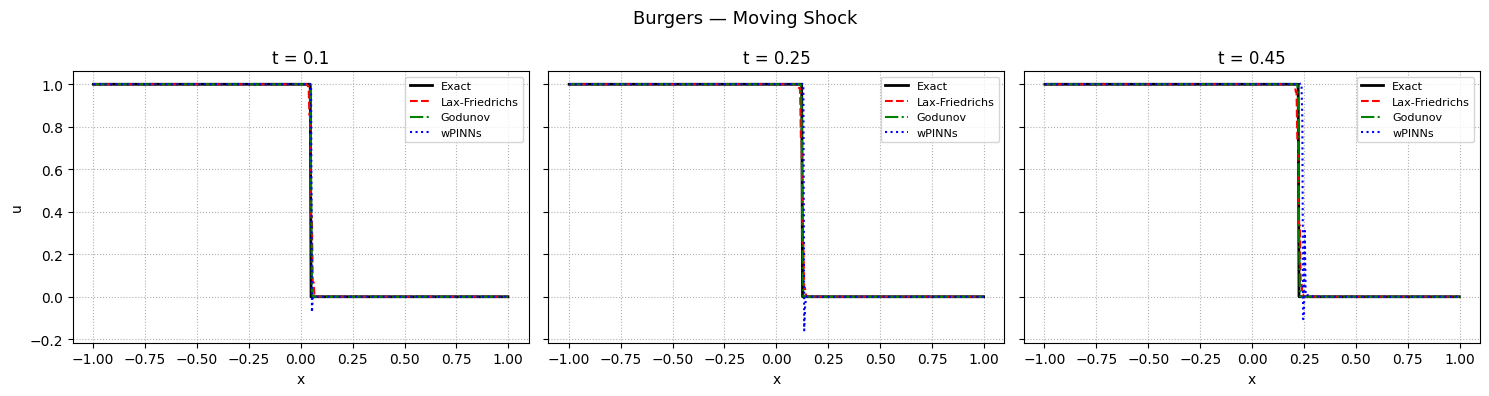

In [10]:
fig, axes = plt.subplots(1, len(TIME_SLICES), figsize=(5 * len(TIME_SLICES), 4), sharey=True)
fig.suptitle("Burgers — Moving Shock", fontsize=13)

for ax, t_q in zip(axes, TIME_SLICES):
    u_ex = exact_solution(case, x_lf_s, t_q)
    u_lf, t_actual = lf_at_time(x_lf_s, t_vec_lf_s, U_lf_s, t_q)
    u_gd, _        = lf_at_time(x_gd_s, t_vec_gd_s, U_gd_s, t_q)

    ax.plot(x_lf_s, u_ex,  "k-",  lw=2,   label="Exact")
    ax.plot(x_lf_s, u_lf,  "r--", lw=1.5, label="Lax-Friedrichs")
    ax.plot(x_gd_s, u_gd,  "g-.", lw=1.5, label="Godunov")
    if model_shock is not None:
        u_wp = wpinns_predict(model_shock, x_lf_s, t_q)
        ax.plot(x_lf_s, u_wp, "b:", lw=1.5, label="wPINNs")

    ax.set_title(f"t = {t_q}")
    ax.set_xlabel("x")
    ax.grid(True, ls=":")
    ax.legend(fontsize=8)

axes[0].set_ylabel("u")
plt.tight_layout()
plt.savefig("comparison_shock_slices.png", dpi=150)
plt.show()

In [11]:
u_ex_final_s = exact_solution(case, x_lf_s, T_FINAL)
u_lf_final_s, _ = lf_at_time(x_lf_s, t_vec_lf_s, U_lf_s, T_FINAL)
u_gd_final_s, _ = lf_at_time(x_gd_s, t_vec_gd_s, U_gd_s, T_FINAL)

print("=== Moving Shock — errors at t = 0.45 ===")
print(f"{'Method':<18} {'L1 error':>12} {'Rel L1 error':>14}")
print("-" * 46)
print(f"{'Lax-Friedrichs':<18} {l1_error(u_lf_final_s, u_ex_final_s):>12.6f} {relative_l1_error(u_lf_final_s, u_ex_final_s):>14.6f}")
print(f"{'Godunov':<18} {l1_error(u_gd_final_s, u_ex_final_s):>12.6f} {relative_l1_error(u_gd_final_s, u_ex_final_s):>14.6f}")
if model_shock is not None:
    u_wp_final_s = wpinns_predict(model_shock, x_lf_s, T_FINAL)
    print(f"{'wPINNs':<18} {l1_error(u_wp_final_s, u_ex_final_s):>12.6f} {relative_l1_error(u_wp_final_s, u_ex_final_s):>14.6f}")

=== Moving Shock — errors at t = 0.45 ===
Method                 L1 error   Rel L1 error
----------------------------------------------
Lax-Friedrichs         0.002867       0.004685
Godunov                0.000758       0.001238
wPINNs                 0.010806       0.017657


---
## Solver convergence study (grid refinement)

Shows how the LF and Godunov errors decrease as the grid is refined. Useful reference for comparing against wPINNs accuracy.

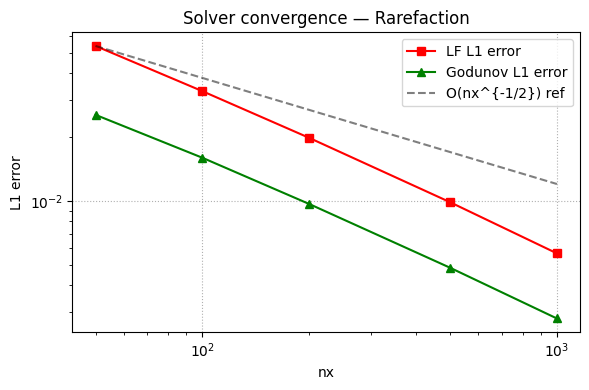


Rarefaction convergence:
      nx        LF L1   Godunov L1
      50     0.053692     0.025433
     100     0.032893     0.015971
     200     0.019824     0.009675
     500     0.009852     0.004838
    1000     0.005657     0.002791


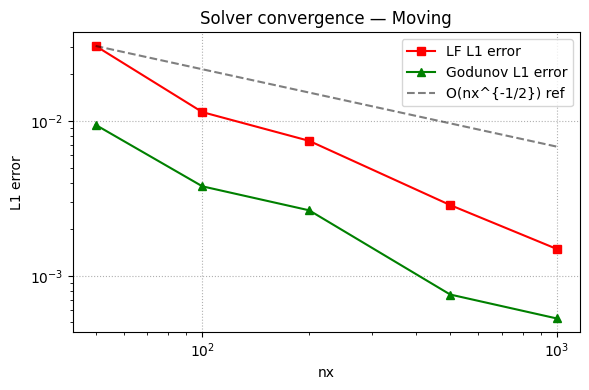


Moving convergence:
      nx        LF L1   Godunov L1
      50     0.030572     0.009453
     100     0.011426     0.003788
     200     0.007454     0.002652
     500     0.002867     0.000758
    1000     0.001491     0.000530


In [12]:
nx_vals = [50, 100, 200, 500, 1000]

for case_c in ["Rarefaction", "Moving"]:
    lf_err = []
    gd_err = []
    for nx in nx_vals:
        xc, tc, Uc = lax_friedrichs(case_c, nx=nx, cfl=0.9)
        lf_err.append(l1_error(Uc[-1], exact_solution(case_c, xc, tc[-1])))

        xg, tg, Ug = godunov(case_c, nx=nx, cfl=0.9)
        gd_err.append(l1_error(Ug[-1], exact_solution(case_c, xg, tg[-1])))

    plt.figure(figsize=(6, 4))
    plt.loglog(nx_vals, lf_err, "rs-", label="LF L1 error")
    plt.loglog(nx_vals, gd_err, "g^-", label="Godunov L1 error")
    # reference slope -1/2 (expected near shocks)
    ref = lf_err[0] * (np.array(nx_vals) / nx_vals[0]) ** (-0.5)
    plt.loglog(nx_vals, ref, "k--", alpha=0.5, label="O(nx^{-1/2}) ref")
    plt.xlabel("nx"); plt.ylabel("L1 error")
    plt.title(f"Solver convergence — {case_c}")
    plt.legend(); plt.grid(True, ls=":")
    plt.tight_layout()
    plt.savefig(f"convergence_{case_c.lower()}.png", dpi=150)
    plt.show()

    print(f"\n{case_c} convergence:")
    print(f"{'nx':>8} {'LF L1':>12} {'Godunov L1':>12}")
    for nx, el, eg in zip(nx_vals, lf_err, gd_err):
        print(f"{nx:>8} {el:>12.6f} {eg:>12.6f}")

---
## Summary table

In [13]:
print("=" * 60)
print(f"  SUMMARY — errors at t = {T_FINAL} (L1 / Rel-L1)")
print("=" * 60)

rows = []
for case_s, x_s, t_s, U_s, xg_s, tg_s, Ug_s, model_s in [
    ("Rarefaction",  x_lf,   t_vec_lf,   U_lf,   x_gd,   t_vec_gd,   U_gd,   model_rar),
    ("Moving shock", x_lf_s, t_vec_lf_s, U_lf_s, x_gd_s, t_vec_gd_s, U_gd_s, model_shock),
]:
    u_ex  = exact_solution(case_s.replace(" shock", "").replace(" ", ""), x_s, T_FINAL)
    u_lf_ = lf_at_time(x_s, t_s, U_s, T_FINAL)[0]
    rows.append((case_s, "Lax-Friedrichs", l1_error(u_lf_, u_ex), relative_l1_error(u_lf_, u_ex)))
    u_gd_ = lf_at_time(xg_s, tg_s, Ug_s, T_FINAL)[0]
    rows.append((case_s, "Godunov", l1_error(u_gd_, u_ex), relative_l1_error(u_gd_, u_ex)))
    if model_s is not None:
        u_wp_ = wpinns_predict(model_s, x_s, T_FINAL)
        rows.append((case_s, "wPINNs", l1_error(u_wp_, u_ex), relative_l1_error(u_wp_, u_ex)))

print(f"{'Case':<16} {'Method':<18} {'L1':>10} {'Rel L1':>10}")
print("-" * 58)
for row in rows:
    print(f"{row[0]:<16} {row[1]:<18} {row[2]:>10.6f} {row[3]:>10.6f}")

  SUMMARY — errors at t = 0.45 (L1 / Rel-L1)
Case             Method                     L1     Rel L1
----------------------------------------------------------
Rarefaction      Lax-Friedrichs       0.009852   0.012713
Rarefaction      Godunov              0.004838   0.006243
Rarefaction      wPINNs               0.028214   0.036404
Moving shock     Lax-Friedrichs       0.002867   0.004685
Moving shock     Godunov              0.000758   0.001238
Moving shock     wPINNs               0.010806   0.017657
